# AkShare 股票数据接口教程

> 基于本项目锁定的 AkShare 版本，覆盖 **134 个实测可用接口**，按投资研究工作流分为 **10 大类**。
>
> 本教程配套文档：`docs/tutorial/akshare.md`、`docs/tutorial/akshare_api_classification.md`

---

In [1]:
# === 环境初始化（必须最先运行）===
# AKShare 的部分接口会使用 tqdm.notebook，需要 ipywidgets 提供 IProgress。
try:
    import ipywidgets
except ImportError as exc:
    raise RuntimeError(
        "当前内核缺少 ipywidgets。请在仓库根目录运行 "
        "`uv sync --project labs`，然后重启内核。"
    ) from exc

print(f"环境初始化完成（ipywidgets {ipywidgets.__version__}）")

环境初始化完成（ipywidgets 8.1.8）


---
## 0. 概述

### 什么是 AkShare

AkShare 是一个开源免费的 Python 金融数据接口库，把东方财富、新浪财经、同花顺、交易所官网等数十个数据源统一封装，安装即用，无需 Token。

### 安装与验证

```bash
pip install akshare --upgrade
```

In [2]:
%matplotlib inline
import pandas as pd
import akshare as ak
from requests import RequestException
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
import mplfinance as mpf

# pandas 3 默认优先使用 pyarrow 字符串；AKShare 1.18.78 的部分正则
# （例如 stock_news_em 中的 \\u3000）需要 Python 正则引擎。
pd.options.mode.string_storage = "python"

print('AkShare 版本:', ak.__version__)
print('可用接口数量:', len(dir(ak)))

CHINESE_FONT_CANDIDATES = [
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC",
    "PingFang SC", "Hiragino Sans GB", "WenQuanYi Micro Hei", "Arial Unicode MS",
]
installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
CHINESE_FONT = next(
    (name for name in CHINESE_FONT_CANDIDATES if name in installed_fonts),
    None,
)
if CHINESE_FONT is None:
    raise RuntimeError(
        "未找到可显示中文的字体，请安装 Microsoft YaHei、SimHei 或 Noto Sans CJK SC。"
    )

matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": [CHINESE_FONT],
    "axes.unicode_minus": False,
    "font.weight": "normal",
})
MPF_CHINESE_STYLE = mpf.make_mpf_style(
    base_mpf_style="yahoo",
    rc={
        "font.family": "sans-serif",
        "font.sans-serif": [CHINESE_FONT],
        "axes.unicode_minus": False,
        "font.weight": "normal",
        "figure.titleweight": "normal",
    },
)
print("Matplotlib 中文字体:", CHINESE_FONT)

AkShare 版本: 1.18.78
可用接口数量: 1149
Matplotlib 中文字体: Microsoft YaHei


### 核心约定

| 参数 | 含义 | 常见取值 |
| --- | --- | --- |
| `symbol` | 标的代码 | 东财 `'600000'`、新浪 `'sh600000'`、雪球 `'SH600000'` |
| `date` | 日期 | `'20241108'`（YYYYMMDD 字符串） |
| `period` | 周期 | `'daily'` / `'weekly'` / `'monthly'` |
| `adjust` | 复权 | `''` 不复权、`'qfq'` 前复权、`'hfq'` 后复权 |

> **命名规律**：`类别_市场_数据类型_源`，如 `stock_zh_a_hist_em` = 股票·A股·历史K线·东方财富

---
## 1. 市场总览与统计

获取市场层面的宏观数据：交易所总貌、每日成交概况、账户开户统计。适合做市场温度计和宏观择时参考。

**可用接口：6 个**

### 可用接口汇总

| 接口 | 数据源 | 参数 |
| --- | --- | --- |
| `stock_sse_summary` | 上海证券交易所 | null |
| `stock_szse_summary` | 深圳证券交易所 | date |
| `stock_szse_area_summary` | 深圳证券交易所 | date |
| `stock_sse_deal_daily` | 上海证券交易所 | date |
| `stock_account_statistics_em` | 东方财富 | null |
| `stock_market_activity_legu` | 乐估乐股 | null |

### 上交所股票市场总貌

In [3]:
# 1. 上交所股票市场总貌（单次返回最近交易日）
df = ak.stock_sse_summary()

print('上交所总貌:', df.shape)

df.head()

上交所总貌: (8, 4)


,项目,股票,主板,科创板
0,流通股本,48517.34,46353.05,2164.29
1,总市值,636018.09,505838.51,130179.58
2,平均市盈率,15.76,13.45,89.10
3,上市公司,2312,1701,611
4,上市股票,2350,1739,611


---
## 2. 标的列表与基础信息

获取全市场股票代码表、个股基础信息、行业分类。这是所有分析的起点——先拿到代码表，再逐个深入。

**可用接口：10 个**

### 可用接口汇总

| 接口 | 数据源 | 参数 |
| --- | --- | --- |
| `stock_info_a_code_name` | 其他 | null |
| `stock_info_bj_name_code` | 北京证券交易所 | null |
| `stock_zh_ah_name` | 腾讯 | null |
| `stock_individual_basic_info_xq` | 雪球 | symbol, token, timeout |
| `stock_individual_basic_info_hk_xq` | 雪球 | symbol, token, timeout |
| `stock_profile_cninfo` | 巨潮资讯 | symbol |
| `stock_ipo_summary_cninfo` | 巨潮资讯 | symbol |
| `stock_info_change_name` | 新浪财经 | symbol |
| `stock_industry_change_cninfo` | 巨潮资讯 | symbol, start_date, end_date |
| `stock_board_industry_summary_ths` | 同花顺 | null |

### A股代码与简称列表

In [4]:
# 1. 全 A 股代码与简称列表（最常用）
df = ak.stock_info_a_code_name()

print('全A股数量:', len(df))

df.head()

  0%|          | 0/17 [00:00<?, ?it/s]

全A股数量: 5531


,code,name
0,000001,平安银行
1,000002,万 科Ａ
2,000006,深振业Ａ
3,000007,全新好
4,000008,神州高铁


---
## 3. 行情数据

实时行情、历史 K 线、分时数据。使用频率最高的一类接口。注意不同数据源对 `symbol` 格式要求不同。

**可用接口：11 个**

### 可用接口汇总

| 接口 | 数据源 | 参数 |
| --- | --- | --- |
| `stock_zh_a_daily` | 新浪财经 | symbol, start_date, end_date, adjust |
| `stock_zh_a_hist_tx` | 腾讯 | symbol, start_date, end_date, adjust, timeout |
| `stock_zh_a_cdr_daily` | 新浪财经 | symbol, start_date, end_date |
| `stock_zh_a_new` | 新浪财经 | null |
| `stock_zh_kcb_spot` | 新浪财经 | null |
| `stock_zh_kcb_daily` | 新浪财经 | symbol, adjust |
| `stock_zh_kcb_report_em` | 东方财富 | from_page, to_page |
| `stock_zh_b_spot` | 新浪财经 | null |
| `stock_individual_spot_xq` | 雪球 | symbol, token, timeout |
| `stock_zh_ah_spot` | 腾讯 | null |
| `stock_hk_spot` | 新浪财经 | null |

### A股历史日K线（新浪）

历史K线: (18, 9)


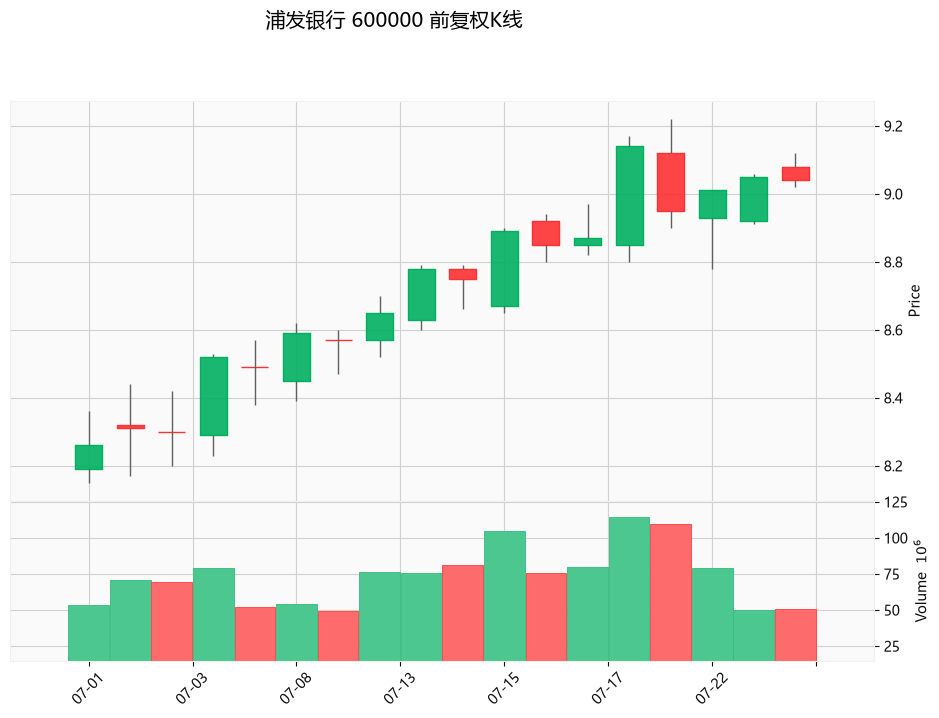

In [3]:
# 1. A股历史日K线（新浪，symbol需带前缀）
df = ak.stock_zh_a_daily(
    symbol='sh600000',
    start_date='20260701',
    end_date='20260724',
    adjust='qfq'  # 前复权
)
print('历史K线:', df.shape)

df.tail()

# 日期处理
df["date"] = pd.to_datetime(df["date"])

# mplfinance要求日期作为index
df = df.set_index("date")

# 中文字段转换
df = df.rename(
    columns={
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "volume": "Volume"
    }
)


mpf.plot(
    df,
    type="candle",
    volume=True,
    figsize=(12,8),
    title="浦发银行 600000 前复权K线",
    datetime_format="%m-%d",
    style=MPF_CHINESE_STYLE
)

### 港股实时行情（新浪）

In [6]:
# 2. 港股实时行情（新浪）
df_hk = ak.stock_hk_spot()

print('港股实时行情:', df_hk.shape)

df_hk.head(3)

  0%|          | 0/99 [00:00<?, ?it/s]

港股实时行情: (2810, 16)


,日期时间,代码,中文名称,英文名称,交易类型,最新价,涨跌额,涨跌幅,昨收,今开,最高,最低,成交量,成交额,买一,卖一
0,2026/07/24 11:59:45,00001,长和,CKH HOLDINGS,,72.25,-0.60,-0.82361,72.85,72.85,72.85,71.90,1844975,133167530,72.15,72.25
1,2026/07/24 11:59:50,00002,中电控股,CLP HOLDINGS,,77.35,-0.05,-0.06460,77.40,77.40,77.70,76.90,821475,63437060,77.30,77.35
2,2026/07/24 11:59:54,00003,香港中华煤气,HK & CHINA GAS,,6.97,-0.01,-0.14327,6.98,6.91,6.98,6.91,9276588,64536664,6.96,6.97


---
## 4. 财务与估值

三大报表、财务指标、估值数据和商誉信息。基本面研究的核心数据来源。

**可用接口：9 个**， 东财三大报表（`stock_zcfz_em` 等）不可用，改用同花顺源。

### 可用接口汇总

| 接口 | 数据源 | 参数 |
| --- | --- | --- |
| `stock_financial_debt_new_ths` | 同花顺 | symbol, indicator |
| `stock_financial_benefit_new_ths` | 同花顺 | symbol, indicator |
| `stock_financial_cash_new_ths` | 同花顺 | symbol, indicator |
| `stock_financial_abstract` | 新浪财经 | symbol |
| `stock_financial_abstract_new_ths` | 同花顺 | symbol, indicator |
| `stock_financial_analysis_indicator` | 新浪财经 | symbol, start_year |
| `stock_zh_valuation_baidu` | 百度股市通 | symbol, indicator, period |
| `stock_value_em` | 东方财富 | symbol |
| `stock_sy_profile_em` | 东方财富 | null |

### 资产负债表（同花顺）

In [7]:
# 1. 同花顺资产负债表
df = ak.stock_financial_debt_new_ths(symbol='600000', indicator='按报告期')

print('资产负债表:', df.shape)

df.head(3)

资产负债表: (5950, 10)


,report_date,report_name,report_period,quarter_name,metric_name,value,single,yoy,mom,single_yoy
0,2026-03-31,2026一季报,2026-1,2026一季度,treasury_stock,,,,,
1,2026-03-31,2026一季报,2026-1,2026一季度,productive_biological_assets,,,,,
2,2026-03-31,2026一季报,2026-1,2026一季度,deferred_tax_debt,633000000.0000,,0.01118211,,


### 关键财务指标（新浪）

In [8]:
# 2. 关键财务指标摘要（新浪）
df_abs = ak.stock_financial_abstract(symbol='sh600000')

print('关键指标:', df_abs.shape)

df_abs.head(3)

关键指标: (80, 109)


,选项,指标,20260331,20251231,20250930,20250630,20250331,20241231,20240930,20240630,...,20011231,20010930,20010630,20001231,20000630,19991231,19990630,19981231,19971231,19961231
0,常用指标,归母净利润,1.786100e+10,5.001700e+10,3.881900e+10,2.973700e+10,1.759800e+10,4.525700e+10,3.522300e+10,2.698800e+10,...,1.061878e+09,8.219933e+08,5.349113e+08,7.970330e+08,5.009706e+08,7.291420e+08,5.059709e+08,7.806024e+08,6.449990e+08,6.291110e+08
1,常用指标,营业总收入,4.657300e+10,1.739640e+11,1.322800e+11,9.055900e+10,4.592200e+10,1.707480e+11,1.298390e+11,8.824800e+10,...,5.069861e+09,2.859229e+09,2.198802e+09,3.394839e+09,1.586769e+09,2.783119e+09,9.215270e+08,2.272001e+09,2.264622e+09,1.878030e+09
2,常用指标,营业成本,2.478400e+10,1.203560e+11,9.007300e+10,5.706100e+10,2.575800e+10,1.233050e+11,9.343400e+10,5.802000e+10,...,2.744718e+09,1.747571e+09,1.120534e+09,2.405483e+09,9.117543e+08,1.915320e+09,6.556816e+08,1.956527e+09,1.673194e+09,1.215210e+09


### A股估值（百度)

In [9]:
# 3. A股估值指标（百度股市通）
df_val = ak.stock_zh_valuation_baidu(symbol='600000', indicator='总市值', period='全部')

print('估值指标:', df_val.shape)

df_val.tail()

估值指标: (610, 2)


,date,value
605,2026-05-21,2950.90
606,2026-06-06,3110.77
607,2026-06-22,3050.81
608,2026-07-08,2997.53
609,2026-07-24,3010.85


---
## 5. 股东与股本变动

十大股东、股东户数、高管持股变动、股本结构等。用于跟踪筹码集中度和内部人交易信号。

**可用接口：12 个**

### 可用接口汇总

| 接口 | 数据源 | 参数 |
| --- | --- | --- |
| `stock_gdfx_free_holding_change_em` | 东方财富 | date |
| `stock_shareholder_change_ths` | 同花顺 | symbol |
| `stock_gdfx_free_holding_analyse_em` | 东方财富 | date |
| `stock_gdfx_holding_analyse_em` | 东方财富 | date |
| `stock_gdfx_free_holding_detail_em` | 东方财富 | date |
| `stock_zh_a_gdhs_detail_em` | 东方财富 | symbol |
| `stock_management_change_ths` | 同花顺 | symbol |
| `stock_share_hold_change_sse` | 上海证券交易所 | symbol |
| `stock_share_change_cninfo` | 巨潮资讯 | symbol, start_date, end_date |
| `stock_zh_a_gbjg_em` | 东方财富 | symbol |
| `stock_circulate_stock_holder` | 新浪财经 | symbol |
| `stock_main_stock_holder` | 新浪财经 | stock |

### 股东持股变动统计

In [10]:
# 1. 股东持股变动统计-十大流通股东（按日期）
df = ak.stock_gdfx_free_holding_change_em(date='20260630')

print('十大流通股东变动:', df.shape)

df.head(10)

  0%|          | 0/1 [00:00<?, ?it/s]

十大流通股东变动: (232, 10)


,序号,股东名称,股东类型,期末持股只数统计-总持有,期末持股只数统计-新进,期末持股只数统计-增加,期末持股只数统计-不变,期末持股只数统计-减少,流通市值统计,持有个股
0,1,香港中央结算有限公司,其他,17,3.0,10.0,NaN,4.0,3.565065e+11,"300750|宁德时代,300409|道氏技术,688475|萤石网络,300708|聚灿光..."
1,2,UBS AG,QFII,6,6.0,NaN,NaN,NaN,1.096012e+10,"300750|宁德时代,300416|苏试试验,300503|昊志机电,600844|金煤科..."
2,3,高盛国际-自有资金,QFII,5,5.0,NaN,NaN,NaN,1.536081e+08,"300416|苏试试验,605228|神通科技,600844|金煤科技,900921|金煤B..."
3,4,J.P.Morgan SecuritiesPLC-自有资金,QFII,4,2.0,2.0,NaN,NaN,5.765769e+08,"600844|金煤科技,900921|金煤B股,688146|中船特气,002150|正泰电源"
4,5,徐前,个人,2,NaN,NaN,2.0,NaN,1.420650e+07,"600844|金煤科技,900921|金煤B股"
5,6,张大龙,个人,2,NaN,NaN,2.0,NaN,2.624328e+07,"600844|金煤科技,900921|金煤B股"
6,7,财通基金-工商银行-富春定增1021号资产管理计划,基金,2,NaN,NaN,2.0,NaN,6.620591e+07,"600844|金煤科技,900921|金煤B股"
7,8,丹阳市丹化运输有限公司,其他,2,NaN,NaN,2.0,NaN,1.982654e+07,"600844|金煤科技,900921|金煤B股"
8,9,高盛公司,QFII,2,1.0,NaN,NaN,1.0,7.420244e+07,"603727|博迈科,002998|优彩资源"
9,10,中电科投资控股有限公司,其他,2,NaN,NaN,2.0,NaN,8.643344e+09,"002415|海康威视,688475|萤石网络"


### 流通股东（新浪）

In [11]:
# 3. 流通股东（新浪）
df_holder = ak.stock_circulate_stock_holder(symbol='sh600000')

print('流通股东:')

df_holder.head()

  0%|          | 0/89 [00:00<?, ?it/s]

流通股东:


,截止日期,公告日期,编号,股东名称,持股数量,占流通股比例,股本性质
0,2026-03-31,2026-04-30,1,上海国际集团有限公司,7086834641,21.278,国有股
1,2026-03-31,2026-04-30,2,中国移动通信集团广东有限公司,6053495450,18.175,国有股
2,2026-03-31,2026-04-30,3,富德生命人寿保险股份有限公司-传统,2779437274,8.345,境内法人股
3,2026-03-31,2026-04-30,4,富德生命人寿保险股份有限公司-资本金,1763232325,5.294,境内法人股
4,2026-03-31,2026-04-30,5,中国东方资产管理股份有限公司,1502726171,4.512,国有股


---
## 6. 资金与筹码

接口最多的大类（**35 个可用**），涵盖资金流向、沪深港通持股、融资融券、龙虎榜、大宗交易、股权质押、主力控盘。是跟踪聪明钱和筹码分布的核心数据。

### 可用接口汇总

| 子类 | 接口 | 数据源 | 参数 |
| --- | --- | --- | --- |
| 资金流 | `stock_fund_flow_big_deal` | 同花顺 | null |
| 沪深港通 | `stock_hsgt_fund_flow_summary_em` | 东方财富 | null |
| 沪深港通 | `stock_hsgt_fund_min_em` | 东方财富 | symbol |
| 沪深港通 | `stock_hsgt_individual_em` | 东方财富 | symbol |
| 沪深港通 | `stock_hsgt_individual_detail_em` | 东方财富 | symbol, start_date, end_date |
| 沪深港通 | `stock_sgt_settlement_exchange_rate_sse` | 上海证券交易所 | null |
| 沪深港通 | `stock_sgt_reference_exchange_rate_sse` | 上海证券交易所 | null |
| 融资融券 | `stock_margin_account_info` | 东方财富 | null |
| 融资融券 | `stock_margin_sse` | 上海证券交易所 | start_date, end_date |
| 融资融券 | `stock_margin_detail_sse` | 上海证券交易所 | date |
| 融资融券 | `stock_margin_szse` | 深圳证券交易所 | date |
| 融资融券 | `stock_margin_detail_szse` | 深圳证券交易所 | date |
| 融资融券 | `stock_margin_underlying_info_szse` | 深圳证券交易所 | date |
| 融资融券 | `stock_margin_bse` | 北京证券交易所 | date |
| 融资融券 | `stock_margin_detail_bse` | 北京证券交易所 | date |
| 融资融券 | `stock_margin_underlying_info_bse` | 北京证券交易所 | date |
| 龙虎榜 | `stock_lhb_detail_em` | 东方财富 | start_date, end_date |
| 龙虎榜 | `stock_lhb_jgmmtj_em` | 东方财富 | start_date, end_date |
| 龙虎榜 | `stock_lh_yyb_most` | 同花顺 | null |
| 龙虎榜 | `stock_lh_yyb_capital` | 同花顺 | null |
| 龙虎榜 | `stock_lh_yyb_control` | 同花顺 | null |
| 龙虎榜 | `stock_lhb_detail_daily_sina` | 新浪财经 | date |
| 龙虎榜 | `stock_lhb_jgzz_sina` | 新浪财经 | symbol |
| 龙虎榜 | `stock_lhb_jgmx_sina` | 新浪财经 | null |
| 大宗交易 | `stock_dzjy_sctj` | 东方财富 | null |
| 大宗交易 | `stock_dzjy_mrtj` | 东方财富 | start_date, end_date |
| 股权质押 | `stock_gpzy_profile_em` | 东方财富 | null |
| 股权质押 | `stock_gpzy_pledge_ratio_em` | 东方财富 | date |
| 股权质押 | `stock_gpzy_individual_pledge_ratio_detail_em` | 东方财富 | symbol |
| 股权质押 | `stock_gpzy_industry_data_em` | 东方财富 | null |
| 股权质押 | `stock_cg_equity_mortgage_cninfo` | 巨潮资讯 | date |
| 主力控盘 | `stock_comment_detail_zlkp_jgcyd_em` | 东方财富 | symbol |
| 主力控盘 | `stock_comment_detail_zhpj_lspf_em` | 东方财富 | symbol |
| 主力控盘 | `stock_comment_detail_scrd_focus_em` | 东方财富 | symbol |
| 主力控盘 | `stock_comment_detail_scrd_desire_em` | 东方财富 | symbol |

### 两融账户信息

In [12]:
# 1. 两融账户信息
df_account = ak.stock_margin_account_info()
print('两融账户:', df_account.shape)
df_account.tail()

  0%|          | 0/7 [00:00<?, ?it/s]

两融账户: (3354, 13)


,日期,融资余额,融券余额,融资买入额,融券卖出额,证券公司数量,营业部数量,个人投资者数量,机构投资者数量,参与交易的投资者数量,有融资融券负债的投资者数量,担保物总价值,平均维持担保比例
3349,2026-07-20,26977.543453,198.001775,2147.690587,16.586196,97,11661,832.6749,53054.0,367209.0,2038451.0,81900.933331,262.4282
3350,2026-07-21,26978.526068,204.141740,2675.866240,13.971004,97,11663,832.9228,53087.0,420379.0,2033103.0,84795.882293,272.2797
3351,2026-07-22,26985.967805,211.620924,2468.613741,18.793814,97,11665,833.1690,53105.0,436448.0,2036621.0,84087.122359,270.0012
3352,2026-07-23,26888.315530,214.632602,1908.499798,11.709306,97,11665,833.3742,53131.0,385966.0,2037944.0,84400.660708,271.2285
3353,2026-07-24,26665.734471,213.458251,1635.893854,12.033258,97,11665,833.5685,53124.0,354952.0,2031190.0,82115.748235,265.3928


### 龙虎榜明细

In [13]:
# 2. 龙虎榜明细（东财）
df_lhb = ak.stock_lhb_detail_em(start_date='20260704', end_date='20260708')

print('龙虎榜明细:', df_lhb.shape)

df_lhb.head()

  0%|          | 0/1 [00:00<?, ?it/s]

龙虎榜明细: (285, 21)


,序号,代码,名称,上榜日,解读,收盘价,涨跌幅,龙虎榜净买额,龙虎榜买入额,龙虎榜卖出额,...,市场总成交额,净买额占总成交比,成交额占总成交比,换手率,流通市值,上榜原因,上榜后1日,上榜后2日,上榜后5日,上榜后10日
0,1,000004,国华退,2026-07-08,普通席位卖出，成功率47.87%,0.38,-5.0000,2.361020e+05,8.973750e+05,6.612730e+05,...,1799704,13.118935,86.605797,3.7205,4.798985e+07,退市整理期,10.526316,21.052632,NaN,NaN
1,2,000004,国华退,2026-07-07,卖一主卖，成功率58.95%,0.40,-2.4390,2.892952e+05,1.860432e+06,1.571137e+06,...,3102426,9.324807,110.609221,6.1298,5.051563e+07,退市整理期,-5.000000,5.000000,NaN,NaN
2,3,000004,国华退,2026-07-06,主力做T，成功率61.95%,0.41,-8.8889,-1.807067e+05,1.495068e+06,1.675774e+06,...,3103588,-5.822509,102.166980,5.5397,5.177852e+07,退市整理期,-2.439024,-7.317073,24.390244,NaN
3,4,000007,全新好,2026-07-07,5家机构卖出，成功率16.67%,11.59,-10.0155,-2.702227e+07,3.465810e+07,6.168037e+07,...,203058414,-13.307633,47.443723,4.8479,4.015333e+09,日振幅值达到15%的前5只证券,-3.364970,-6.384815,-12.165660,-23.554789
4,5,000066,中国长城,2026-07-06,1家机构买入，成功率46.95%,18.82,9.9942,6.270860e+08,9.313754e+08,3.042893e+08,...,3729009536,16.816424,33.136538,6.3972,6.070485e+10,日涨幅偏离值达到7%的前5只证券,-1.275239,2.603613,-4.091392,-23.485654


In [14]:
# 3. 龙虎榜机构买卖统计
df_jg = ak.stock_lhb_jgmmtj_em(start_date='20260704', end_date='20260708')

print('机构买卖统计:', df_jg.shape)

df_jg.head()

  0%|          | 0/1 [00:00<?, ?it/s]

机构买卖统计: (167, 16)


,序号,代码,名称,收盘价,涨跌幅,买方机构数,卖方机构数,机构买入总额,机构卖出总额,机构买入净额,市场总成交额,机构净买额占总成交额比,换手率,流通市值,上榜原因,上榜日期
0,1,001399,惠科股份,34.78,-8.7618,3,4,1.182645e+09,8.437497e+08,3.388948e+08,11154753313,3.038120,26.1115,149.75,连续三个交易日内，跌幅偏离值累计达到20%的证券,2026-07-07
1,2,002636,金安国纪,96.79,-9.4998,3,0,4.988138e+08,1.766227e+08,3.221911e+08,6876329037,4.685511,9.2175,701.06,日振幅值达到15%的前5只证券,2026-07-06
2,3,001399,惠科股份,38.12,-9.5396,4,3,7.892802e+08,4.906711e+08,2.986091e+08,6010094635,4.968459,35.2974,164.13,日换手率达到20%的前5只证券,2026-07-06
3,4,002245,蔚蓝锂芯,22.37,9.9803,4,3,1.042586e+09,7.557041e+08,2.868822e+08,9417287170,3.046336,8.4973,359.40,连续三个交易日内，涨幅偏离值累计达到20%的证券,2026-07-06
4,5,002185,华天科技,21.93,9.9799,1,2,4.044900e+08,2.130730e+08,1.914170e+08,11999102685,1.595261,16.9334,728.66,日涨幅偏离值达到7%的前5只证券,2026-07-07


### 股权质押 + 主力控盘 

In [15]:
# 4. 股权质押市场概况
df_gpzy = ak.stock_gpzy_profile_em()

print('股权质押概况:', df_gpzy.shape)

df_gpzy.tail()

股权质押概况: (632, 8)


,交易日期,A股质押总比例,质押公司数量,质押笔数,质押总股数,质押总市值,沪深300指数,涨跌幅
627,2026-06-26,2.860778,2229,13296,28495988.98,2.864407e+08,4868.2205,-1.4849
628,2026-07-03,2.848569,2224,13315,28496396.25,2.871506e+08,4842.1737,-0.5350
629,2026-07-10,2.797998,2223,13341,28438073.87,2.738938e+08,4780.7867,-1.2678
630,2026-07-17,2.751099,2217,13386,28473907.97,2.538658e+08,4529.0953,-5.2646
631,2026-07-24,2.684140,2207,13465,28445077.18,2.491359e+08,4649.1917,2.6517


In [16]:
# 5. 主力控盘-机构参与度
df_zlkp = ak.stock_comment_detail_zlkp_jgcyd_em(symbol='600000')

print('机构参与度:', df_zlkp.shape)

df_zlkp.tail()

机构参与度: (44, 2)


,交易日,机构参与度
39,2026-07-20,34.02736
40,2026-07-21,28.64516
41,2026-07-22,28.86556
42,2026-07-23,27.85876
43,2026-07-24,32.20860


---
## 7. IPO 与资本运作

可用率最高的大类（26/36 ≈ 72%），涵盖新股发行、IPO 审核、增发配股回购、限售解禁、分红派息、股东大会。适合做事件驱动和打新策略研究。

### 可用接口汇总

| 子类 | 接口 | 数据源 | 参数 |
| --- | --- | --- | --- |
| 新股发行 | `stock_dxsyl_em` | 东方财富 | null |
| 新股发行 | `stock_ipo_hk_ths` | 同花顺 | null |
| 新股发行 | `stock_ipo_info` | 新浪财经 | stock |
| 新股发行 | `stock_new_ipo_cninfo` | 巨潮资讯 | null |
| IPO审核 | `stock_ipo_review_em` | 东方财富 | null |
| IPO审核 | `stock_ipo_tutor_em` | 东方财富 | null |
| IPO审核 | `stock_ipo_declare_em` | 东方财富 | null |
| IPO审核 | `stock_register_all_em` | 东方财富 | null |
| IPO审核 | `stock_register_kcb` | 东方财富 | null |
| IPO审核 | `stock_register_cyb` | 东方财富 | null |
| IPO审核 | `stock_register_sh` | 东方财富 | null |
| IPO审核 | `stock_register_sz` | 东方财富 | null |
| IPO审核 | `stock_register_bj` | 东方财富 | null |
| IPO审核 | `stock_register_db` | 东方财富 | null |
| 增发/回购 | `stock_add_stock` | 新浪财经 | symbol |
| 增发/回购 | `stock_qbzf_em` | 东方财富 | null |
| 增发/回购 | `stock_pg_em` | 东方财富 | null |
| 增发/回购 | `stock_repurchase_em` | 东方财富 | null |
| 限售解禁 | `stock_restricted_release_queue_sina` | 新浪财经 | symbol |
| 限售解禁 | `stock_restricted_release_detail_em` | 东方财富 | start_date, end_date |
| 限售解禁 | `stock_restricted_release_queue_em` | 东方财富 | symbol |
| 分红 | `stock_fhps_detail_em` | 东方财富 | symbol |
| 分红 | `stock_fhps_detail_ths` | 同花顺 | symbol |
| 分红 | `stock_history_dividend` | 新浪财经 | null |
| 分红 | `stock_dividend_cninfo` | 巨潮资讯 | symbol |
| 股东大会 | `stock_gddh_em` | 东方财富 | null |

### IPO 审核

In [17]:
# 1. 新股上会信息
df = ak.stock_ipo_review_em()

print('新股上会:', df.shape)

df.head(3)

  0%|          | 0/11 [00:00<?, ?it/s]

新股上会: (5264, 13)


,序号,企业名称,股票简称,股票代码,上市板块,上会日期,审核状态,发审委委员,主承销商,发行数量(股),拟融资额(元),公告日期,上市日期
0,1,苏州猎奇智能设备股份有限公司,猎奇智能,A25297,深交所创业板,2026-07-31,未上会,"王灵钰,沈哲,张勇,贾蕊,喻婕",国泰海通证券,13750000,9.134139e+08,2026-07-14,NaT
1,2,江苏方意摩擦材料股份有限公司,方意股份,A24054,北交所,2026-07-24,上会通过,"尹舒,李学峰,耿晨晨,李倩,于竹丽",东吴证券,13907100,1.760000e+04,2025-12-31,NaT
2,3,内蒙古旭阳新材料股份有限公司,旭阳新材,A25231,北交所,2026-07-24,上会通过,"蔡慧,王澎涛,吴海峰,李中全,杨超颖",长江证券,39640600,5.504597e+04,2025-12-30,NaT


In [18]:
# 2. IPO审核信息-全部
df_reg = ak.stock_register_all_em()

print('IPO审核:', df_reg.shape)

df_reg.head()

  0%|          | 0/9 [00:00<?, ?it/s]

IPO审核: (4398, 12)


,序号,企业名称,最新状态,注册地,行业,保荐机构,律师事务所,会计师事务所,更新日期,受理日期,拟上市地点,招股说明书
0,1,北京市九州风神科技股份有限公司,终止,北京市 海淀区,计算机、通信和其他电子设备制造业,中信建投证券股份有限公司,广东君言律师事务所,容诚会计师事务所(特殊普通合伙),2026-07-24,2023-11-10,北交所,https://pdf.dfcfw.com/pdf/H2_AN202311101609901...
1,2,江苏方意摩擦材料股份有限公司,上市委会议通过,江苏省 盐城市,汽车制造业,东吴证券股份有限公司,北京德恒律师事务所,中汇会计师事务所(特殊普通合伙),2026-07-24,2025-12-31,北交所,https://pdf.dfcfw.com/pdf/H2_AN202607171827065...
2,3,新疆凯龙清洁能源股份有限公司,终止,新疆维吾尔自治区 克拉玛依市,开采专业及辅助性活动,浙商证券股份有限公司,上海市广发律师事务所,信永中和会计师事务所(特殊普通合伙),2026-07-24,2025-12-31,北交所,https://pdf.dfcfw.com/pdf/H2_AN202512311812086...
3,4,朝阳金达钛业股份有限公司,注册,辽宁省 朝阳市,有色金属冶炼和压延加工业,中信建投证券股份有限公司,北京市君致律师事务所,中审众环会计师事务所(特殊普通合伙),2026-07-24,2024-12-31,北交所,https://pdf.dfcfw.com/pdf/H2_AN202606181823669...
4,5,德阳天元重工股份有限公司,已问询,四川省 德阳市,金属制品业,第一创业证券承销保荐有限责任公司,北京市中伦律师事务所,信永中和会计师事务所(特殊普通合伙),2026-07-24,2025-12-30,北交所,https://pdf.dfcfw.com/pdf/H2_AN202607241827328...


### 增发/回购

In [19]:
# === 增发/回购 + 解禁 + 分红 ===
# 3. 股票回购数据
df_repurchase = ak.stock_repurchase_em()

print('股票回购:', df_repurchase.shape)

df_repurchase.head()

股票回购: (5385, 18)


,序号,股票代码,股票简称,最新价,计划回购价格区间,计划回购数量区间-下限,计划回购数量区间-上限,占公告前一日总股本比例-下限,占公告前一日总股本比例-上限,计划回购金额区间-下限,计划回购金额区间-上限,回购起始时间,实施进度,已回购股份价格区间-下限,已回购股份价格区间-上限,已回购股份数量,已回购金额,最新公告日期
0,1,603950,长源东谷,59.80,70.00,2142900.0,4285700.0,0.661122,1.322213,150000000.0,300000000.0,2026-07-24,董事会预案,NaN,NaN,NaN,NaN,2026-07-25
1,2,603939,益丰药房,21.78,30.56,6544500.0,9816800.0,0.539800,0.809705,200000000.0,300000000.0,2026-07-24,董事会预案,NaN,NaN,NaN,NaN,2026-07-25
2,3,603516,淳中科技,89.06,173.61,288100.0,576000.0,0.141734,0.283369,50000000.0,100000000.0,2026-07-24,董事会预案,NaN,NaN,NaN,NaN,2026-07-25
3,4,603079,圣达生物,10.04,15.00,1100000.0,2000000.0,0.581919,1.058035,16500000.0,30000000.0,2026-07-24,董事会预案,NaN,NaN,NaN,NaN,2026-07-25
4,5,600155,华创云信,5.53,8.36,11960000.0,23920000.0,0.540310,1.080621,100000000.0,200000000.0,2026-07-24,董事会预案,NaN,NaN,NaN,NaN,2026-07-25


### 限售股解禁

In [20]:
# 4. 限售股解禁详情
df_release = ak.stock_restricted_release_detail_em(start_date='20260101', end_date='20260630')

print('限售解禁:', df_release.shape)

df_release.tail()

限售解禁: (736, 12)


,序号,股票代码,股票简称,解禁时间,限售股类型,解禁数量,实际解禁数量,实际解禁市值,占解禁前流通市值比例,解禁前一交易日收盘价,解禁前20日涨跌幅,解禁后20日涨跌幅
731,732,301105,鸿铭股份,2026-06-30,"首发原股东限售股份,追加承诺限售股份上市流通",33562503.0,3375001.0,1.450575e+08,0.170347,42.98,-18.829707,-7.49
732,733,001369,双欣材料,2026-06-30,首发机构配售股份,6424045.0,6424045.0,8.685309e+07,0.030966,13.52,-7.813571,-8.70
733,734,301448,开创电气,2026-06-30,首发原股东限售股份,56160000.0,22600500.0,1.025611e+09,0.318842,45.38,33.915575,-17.24
734,735,600789,鲁抗医药,2026-06-30,定向增发机构配售股份,111628565.0,111628565.0,7.601905e+08,0.110491,6.81,-5.837563,-3.64
735,736,688582,芯动联科,2026-06-30,首发原股东限售股份,151520000.0,151520000.0,9.848800e+09,0.377160,65.00,23.634497,-39.20


### 分红配送

In [21]:
# 5. 分红配送详情
df_div = ak.stock_fhps_detail_em(symbol='600000')

print('分红配送:', df_div.shape)

df_div.tail()

  0%|          | 0/1 [00:00<?, ?it/s]

分红配送: (26, 19)


,报告期,业绩披露日期,送转股份-送转总比例,送转股份-送股比例,送转股份-转股比例,现金分红-现金分红比例,现金分红-现金分红比例描述,现金分红-股息率,每股收益,每股净资产,每股公积金,每股未分配利润,净利润同比增长,总股本,预案公告日,股权登记日,除权除息日,方案进度,最新公告日期
21,2021-12-31,2022-04-28,NaN,NaN,NaN,4.10,"10派4.10元(含税,扣税后3.69元)",0.052632,1.62,19.08,2.785568,6.578632,-9.124732,29352173289,2022-04-28,2022-07-20,2022-07-21,实施分配,2022-07-13
22,2022-12-31,2023-04-19,NaN,NaN,NaN,3.20,"10派3.20元(含税,扣税后2.88元)",0.043127,1.56,20.03,2.785568,6.923549,-3.456408,29352175642,2023-04-19,2023-07-20,2023-07-21,实施分配,2023-07-13
23,2023-12-31,2024-04-30,NaN,NaN,NaN,3.21,"10派3.21元(含税,扣税后2.889元)",0.035509,1.07,20.95,2.785568,7.097745,-28.275781,29352177375,2024-04-30,2024-07-17,2024-07-18,实施分配,2024-07-11
24,2024-12-31,2025-03-29,NaN,NaN,NaN,4.10,"10派4.10元(含税,扣税后3.69元)",0.029433,1.36,22.36,2.790985,7.849584,23.309356,30267679579,2025-03-29,2025-07-15,2025-07-16,实施分配,2025-07-10
25,2025-12-31,2026-03-31,NaN,NaN,NaN,4.20,"10派4.20元(含税,扣税后3.78元)",0.045113,1.52,22.13,4.037140,7.535069,10.517710,33305838300,2026-03-31,2026-07-15,2026-07-16,实施分配,2026-07-10


---
## 8. 机构与研究

机构调研、机构持股、分析师排行、个股研报。用于跟踪机构观点和聪明钱动向。

**可用接口：7 个**

### 可用接口汇总

| 接口 | 数据源 | 参数 |
| --- | --- | --- |
| `stock_jgdy_tj_em` | 东方财富 | date |
| `stock_zyjs_ths` | 同花顺 | symbol |
| `stock_fund_stock_holder` | 新浪财经 | symbol |
| `stock_research_report_em` | 东方财富 | symbol |
| `stock_analyst_rank_em` | 东方财富 | year |
| `stock_comment_em` | 东方财富 | null |
| `stock_rank_forecast_cninfo` | 巨潮资讯 | date |

### 机构调研统计

In [22]:
# 1. 机构调研统计（东财，按日期）
df = ak.stock_jgdy_tj_em(date='20260708')

print('机构调研:', df.shape)

df.head(3)

机构调研: (724, 11)


,序号,代码,名称,最新价,涨跌幅,接待机构数量,接待方式,接待人员,接待地点,接待日期,公告日期
0,1,600720,中交设计,5.08,-2.31,9,"特定对象调研,路演活动","董事会办公室执行总经理 赵凯,证券事务代表 张彦拓",NaN,2026-07-20,2026-07-25
1,2,603517,ST绝味,10.02,-1.67,8,特定对象调研,副总裁、董事会秘书 廖凯,公司29楼会议室,2026-07-21,2026-07-25
2,3,300416,苏试试验,13.61,-2.37,82,电话会议,"董事长 钟琼华,副总经理、董事会秘书 骆星烁,投资者关系总监 向雪莹,证券事务代表 汪雨欣",电话会议,2026-07-24,2026-07-24


### 个股研报（东财）

In [23]:
# 2. 个股研报（东财）
df_report = ak.stock_research_report_em(symbol='600000')

print('个股研报:', df_report.shape)

df_report.head(3)

  0%|          | 0/1 [00:00<?, ?it/s]

个股研报: (39, 16)


,序号,股票代码,股票简称,报告名称,东财评级,机构,近一月个股研报数,2026-盈利预测-收益,2026-盈利预测-市盈率,2027-盈利预测-收益,2027-盈利预测-市盈率,2028-盈利预测-收益,2028-盈利预测-市盈率,行业,日期,报告PDF链接
0,1,600000,浦发银行,2025年报点评：净息差企稳，资产质量改善,中性,国信证券,0,1.53,6.6,1.68,5.9,1.82,5.5,银行Ⅱ,2026-03-31,https://pdf.dfcfw.com/pdf/H3_AP202603311820916...
1,2,600000,浦发银行,2025年中报点评：资产质量改善,中性,国信证券,0,1.62,8.7,1.81,7.8,NaN,NaN,银行Ⅱ,2025-08-28,https://pdf.dfcfw.com/pdf/H3_AP202508281735932...
2,3,600000,浦发银行,2024年三季报点评：信贷结构优化，资产质量稳定,中性,国信证券,0,1.38,7.2,NaN,NaN,NaN,NaN,银行Ⅱ,2024-10-31,https://pdf.dfcfw.com/pdf/H3_AP202410311640632...


### 分析师指数排行

In [24]:
# 3. 分析师指数排行
df_analyst = ak.stock_analyst_rank_em(year='2026')

print('分析师排行:', df_analyst.shape)

df_analyst.head()

  0%|          | 0/2 [00:00<?, ?it/s]

分析师排行: (100, 16)


,序号,分析师名称,分析师单位,年度指数,2026年收益率,3个月收益率,6个月收益率,12个月收益率,成分股个数,2026最新个股评级-股票名称,2026最新个股评级-股票代码,分析师ID,行业代码,行业,更新日期,年度
0,1,颜枫,上海证券,4996.07,169.48,64.27,154.66,235.82,1,芯碁微装,688630,11000495635,NaN,NaN,2026-07-24,2026
1,2,方晨,上海证券,2672.03,118.36,49.36,83.02,154.50,1,鼎龙股份,300054,11000327334,610000,建筑材料,2026-07-24,2026
2,3,邱净博,广发证券,2519.33,116.28,77.27,104.40,151.93,0,长盈通,688143,11000325033,NaN,NaN,2026-07-24,2026
3,4,要文强,东北证券,4500.96,111.63,25.76,95.92,205.21,0,斯迪克,300806,11000400832,730000,通信,2026-07-24,2026
4,5,翟一梦,中邮证券,1927.63,94.63,21.21,40.77,92.76,5,广立微,301095,11000469936,NaN,NaN,2026-07-24,2026


---
## 9. 公告与事件异动

停复牌通知、异动股池、技术形态选股、重大合同、内部交易、险资举牌。适合做事件驱动和异动监控。

**可用接口：12 个**

### 可用接口汇总

| 接口 | 数据源 | 参数 |
| --- | --- | --- |
| `stock_tfp_em` | 东方财富 | date |
| `news_trade_notify_suspend_baidu` | 百度股市通 | date |
| `news_trade_notify_dividend_baidu` | 百度股市通 | date, cookie |
| `stock_board_change_em` | 东方财富 | null |
| `stock_zdhtmx_em` | 东方财富 | start_date, end_date |
| `stock_gsrl_gsdt_em` | 东方财富 | date |
| `stock_rank_cxfl_ths` | 同花顺 | null |
| `stock_rank_cxsl_ths` | 同花顺 | null |
| `stock_rank_ljqs_ths` | 同花顺 | null |
| `stock_rank_xzjp_ths` | 同花顺 | null |
| `stock_inner_trade_xq` | 雪球 | null |
| `news_report_time_baidu` | 百度股市通 | date |

### 停复牌通知（东财）

In [25]:
# 1. 停复牌通知（东财）
df = ak.stock_tfp_em(date='20260724')

print('停复牌:', df.shape)

df.head()

停复牌: (10, 9)


,序号,代码,名称,停牌时间,停牌截止时间,停牌期限,停牌原因,所属市场,预计复牌时间
0,0,300615,欣天科技,2026-07-27,NaT,连续停牌,刊登重要公告,深交所创业板,NaT
1,1,300996,普联软件,2026-07-27,NaT,连续停牌,刊登重要公告,深交所创业板,NaT
2,2,688089,嘉必优,2026-07-27,2026-07-27,停牌一天,刊登重要公告,上交所科创板,2026-07-28
3,3,002828,贝肯能源,2026-07-27,NaT,连续停牌,刊登重要公告,深交所主板,NaT
4,4,300955,嘉亨家化,2026-07-24,NaT,连续停牌,刊登重要公告,深交所创业板,NaT


### 技术形态选股-持续放量

In [26]:
# 2. 技术形态选股-持续放量
df_cxfl = ak.stock_rank_cxfl_ths()

print('持续放量:', df_cxfl.shape)

df_cxfl.head()

  0%|          | 0/1 [00:00<?, ?it/s]

持续放量: (21, 10)


,序号,股票代码,股票简称,涨跌幅,最新价,成交量,基准日成交量,放量天数,阶段涨跌幅,所属行业
0,1,300875,捷强装备,-2.21,32.81,1280.70万,156.65万(07月16日),6,14.04,军工装备
1,2,300443,金雷股份,0.05,20.60,974.17万,375.80万(07月16日),6,7.97,风电设备
2,3,605288,凯迪股份,2.55,69.24,182.96万,112.72万(07月20日),4,25.39,自动化设备
3,4,603383,顶点软件,2.66,28.59,583.82万,378.96万(07月20日),4,9.54,软件开发
4,5,601061,中信金属,-7.72,10.76,2445.20万,1657.56万(07月20日),4,7.60,贸易


### 险资举牌

In [27]:
# 3. 险资举牌
df_xzjp = ak.stock_rank_xzjp_ths()

print('险资举牌:', df_xzjp.shape)

df_xzjp.head()

险资举牌: (32, 12)


,序号,举牌公告日,股票代码,股票简称,现价,涨跌幅,举牌方,增持数量,交易均价,增持数量占总股本比例,变动后持股总数,变动后持股比例
0,1,2026-07-25,000598,兴蓉环境,7.26,-2.29,信环绿色控股(北京)有限责任公司,2985.66万,7.19,1.00,2.42亿,8.12
1,2,2026-07-23,003008,开普检测,16.31,-2.80,"陕西华富新能源有限公司,仵博",529.11万,17.68,5.09,529.11万,5.09
2,3,2026-07-18,000598,兴蓉环境,7.26,-2.29,信环绿色控股(北京)有限责任公司,2985.68万,6.80,1.00,2.12亿,7.12
3,4,2026-07-17,300929,华骐环保,14.79,4.45,"王根九,王凤仙,王健业,王悦",114.67万,15.22,0.87,1982.00万,15.00
4,5,2026-07-16,002322,理工能科,9.83,-2.48,M&G (ACS)-M&G (ACS) China Fund...,33.44万,9.87,0.09,1838.38万,5.03


---
## 10. 市场情绪、互动与 ESG

股票热度排名、新闻资讯、ESG 评级。适合做情绪因子和舆情分析。

**可用接口：6 个**

### 可用接口汇总

| 接口 | 数据源 | 参数 |
| --- | --- | --- |
| `stock_hot_rank_latest_em` | 东方财富 | symbol |
| `stock_hk_hot_rank_latest_em` | 东方财富 | symbol |
| `stock_news_em` | 东方财富 | symbol |
| `stock_news_main_cx` | 财新 | null |
| `stock_esg_rft_sina` | 新浪财经 | null |
| `stock_esg_hz_sina` | 新浪财经 | null |

### 个股新闻（东财）

In [28]:
# 个股新闻（东财）
df_news = ak.stock_news_em(symbol='600000')

print('个股新闻:', df_news.shape)

df_news.head(3)

个股新闻: (10, 6)


,关键词,新闻标题,新闻内容,发布时间,文章来源,新闻链接
0,600000,煌上煌：首次回购公司股份600000股,证券日报网讯 7月22日，煌上煌发布公告称，公司于2026年7月22日首次通过集中竞价方式实...,2026-07-22 21:20:00,证券日报,http://finance.eastmoney.com/a/202607223817648...
1,600000,600000管理层，直面股东“灵魂拷问”,6月26日，浦发银行（600000）在上海召开2025年年度股东大会。 时隔1年再次走进浦发...,2026-06-26 21:38:00,上海证券报,http://finance.eastmoney.com/a/202606263785074...
2,600000,中证银行指数上半年回调12.74%，7月反弹超7%！银行迎半年报窗口，板块或迎来价值重估机遇,消息面上，7月20日晚间，渝农商行（601077.SH）、重庆银行（601963.SH）及浦...,2026-07-22 15:55:29,21世纪经济报道,http://finance.eastmoney.com/a/202607223817268...


---
## 总结

### 接口选择策略

1. **优先选可用接口**：本教程列出的 134 个接口均经过实测验证
2. **多源互备**：同一主题在多个数据源下有覆盖，源 A 不可用时切到源 B
3. **注意 symbol 格式**：东财 `'600000'`，新浪 `'sh600000'`，雪球 `'SH600000'`
4. **日期格式统一**：`date` / `start_date` / `end_date` 均为 `'YYYYMMDD'` 字符串

### 进一步学习

- 完整文档：`docs/tutorial/akshare.md`
- 分类总览：`docs/tutorial/akshare_api_classification.md`
- 可用接口清单：`akshare.api.xlsx`
- AkShare 官方文档：https://akshare.akfamily.xyz